In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [47]:
data = pd.read_csv('data/Blood_samples_dataset_balanced_2(f).csv')

print('Tamaño del dataset:', data.shape)
print('\nClases:')
print(data['Disease'].value_counts())


Tamaño del dataset: (2351, 25)

Clases:
Disease
Anemia      623
Healthy     556
Diabetes    540
Thalasse    509
Thromboc    123
Name: count, dtype: int64


RFE

In [48]:
X=data.drop('Disease', axis=1)
y=data['Disease']

print("Dimension de X: ", X.shape)
print("Dimension de y: ", y.shape)

Dimension de X:  (2351, 24)
Dimension de y:  (2351,)


In [62]:
#vemos la importancia de todas las caracteristicas
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X, y)

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

print('Importancia de cada biomarcador:\n')
print(importancias.round(4))

Importancia de cada biomarcador:

Mean Corpuscular Hemoglobin                  0.1074
White Blood Cells                            0.0795
Hematocrit                                   0.0672
Platelets                                    0.0651
Red Blood Cells                              0.0576
HDL Cholesterol                              0.0546
ALT                                          0.0404
Troponin                                     0.0402
Mean Corpuscular Hemoglobin Concentration    0.0402
AST                                          0.0378
Mean Corpuscular Volume                      0.0377
HbA1c                                        0.0365
Cholesterol                                  0.0364
LDL Cholesterol                              0.0353
Heart Rate                                   0.0323
Systolic Blood Pressure                      0.0289
Diastolic Blood Pressure                     0.0275
C-reactive Protein                           0.0266
Glucose                       

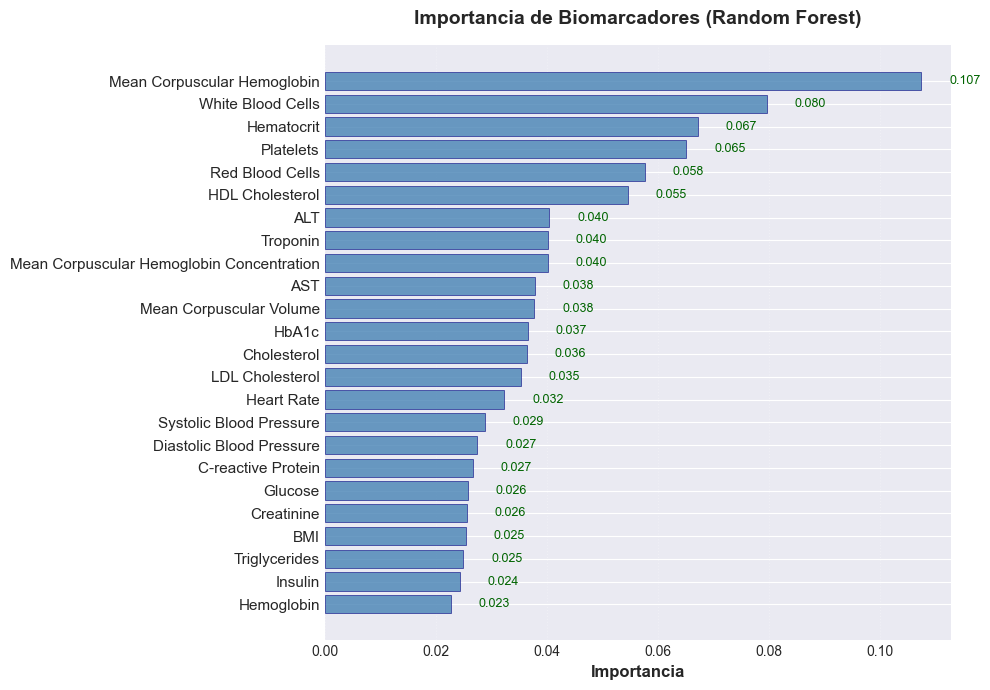

In [63]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(10, 7))

importancias_ordenadas = importancias.sort_values()
bars = plt.barh(range(len(importancias_ordenadas)), importancias_ordenadas.values, 
                color='steelblue', alpha=0.8, edgecolor='navy', linewidth=0.5)

plt.yticks(range(len(importancias_ordenadas)), importancias_ordenadas.index, fontsize=11)
plt.xlabel('Importancia', fontsize=12, fontweight='bold')
plt.title('Importancia de Biomarcadores (Random Forest)', fontsize=14, fontweight='bold', pad=15)

for i, (idx, val) in enumerate(importancias_ordenadas.items()):
    plt.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=9, color='darkgreen')

plt.grid(axis='x', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

In [ ]:
modelo = RandomForestClassifier(random_state=42)

rfe = RFE(modelo, n_features_to_select=10) #se dejan solo las 10 mas importantes
rfe.fit(X, y)

seleccionadas = X.columns[rfe.support_].tolist()

print(f'Selwccionadas ({len(seleccionadas)}):')
for f in seleccionadas:
    print(f'{f}')

Selwccionadas (10):
Platelets
White Blood Cells
Red Blood Cells
Hematocrit
Mean Corpuscular Volume
Mean Corpuscular Hemoglobin
Mean Corpuscular Hemoglobin Concentration
HDL Cholesterol
ALT
Heart Rate


Reducción de Dimensionalidad con PCA

In [56]:
X_redicido = X[seleccionadas]
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X_redicido)

In [64]:
#saber con cuantas caracteristicas se puede cubrir mas info
pca_completo = PCA()
pca_completo.fit(X_escalado)

varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_) * 100

n_90 = int(np.argmax(varianza_acumulada >= 90)) + 1 #con cuanto se cubre el 90%
print(f'Con {n_90} componentes cubrimos el 90% de la información del dataset')

Con 9 componentes cubrimos el 90% de la información del dataset


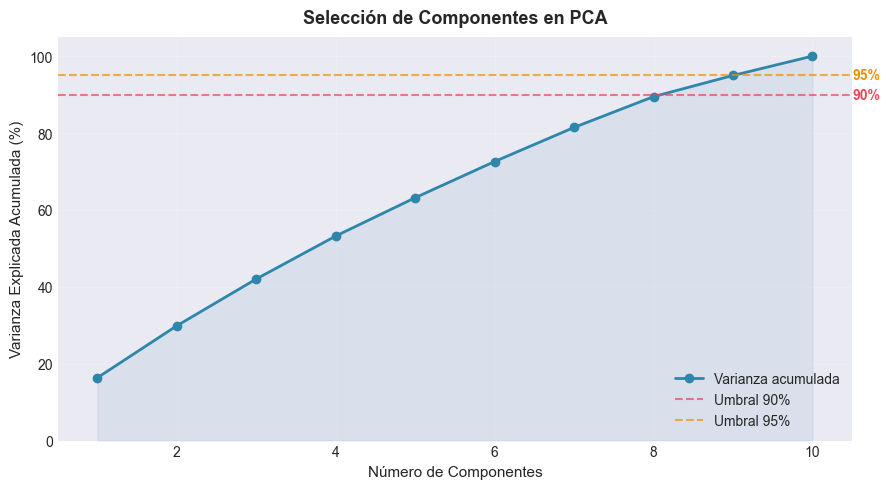

In [65]:
plt.figure(figsize=(9, 5))

plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada, 
         'o-', color='#2E86AB', linewidth=2, markersize=6, label='Varianza acumulada')

umbrales = [90, 95]
colores = ['#E84855', '#F18F01']
for umbral, color in zip(umbrales, colores):
    plt.axhline(umbral, color=color, linestyle='--', linewidth=1.5, alpha=0.7, 
                label=f'Umbral {umbral}%')
    
   
    plt.text(len(varianza_acumulada)+0.5, umbral, f'{umbral}%', 
             color=color, fontweight='bold', va='center')

plt.xlabel('Número de Componentes', fontsize=11)
plt.ylabel('Varianza Explicada Acumulada (%)', fontsize=11)
plt.title('Selección de Componentes en PCA', fontsize=13, fontweight='bold', pad=10)


plt.grid(True, alpha=0.2)
plt.xlim(0.5, len(varianza_acumulada)+0.5)
plt.ylim(0, 105)


plt.fill_between(range(1, len(varianza_acumulada)+1), 0, varianza_acumulada, 
                alpha=0.1, color='steelblue')

plt.legend(loc='lower right', fontsize=10, framealpha=0.9, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()

In [66]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_escalado)

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100
print(f'PC1 explica: {var1:.1f}%')
print(f'PC2 explica: {var2:.1f}%')
print(f'Total:       {var1+var2:.1f}%')

PC1 explica: 16.3%
PC2 explica: 13.5%
Total:       29.9%
